This file makes plots showing the contributions to radiative forcing grouped by ecoregions and political regions. The dataset come from avergae values assigned to individual fire scars.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('/Users/hrchapmandutton/Documents/Projects/CDW/all_fires_2001_2019_clip_single_burn_w_regions.csv')
df.columns

Index(['FID', 'NAME', 'RECORDNUMB', 'ACRES', 'PERIMETERD', 'SOURCE',
       'SOURCEMETH', 'SOURCECLAS', 'AGENCYACRE', 'COMMENTS', 'FIREID',
       'FIREYEAR', 'UPDATETIME', 'FPOUTDATE', 'IRWINID', 'PRESCRIBED',
       'FIRESEASON', 'UniqueID', 'area_sqkm', 'SRC_AGENCY', 'NAT_PARK',
       'MONTH', 'DAY', 'REP_DATE', 'DATE_TYPE', 'DECADE', 'SIZE_HA', 'CALC_HA',
       'SOURCE_KEY', 'MORE_INFO', 'CFS_REF_ID', 'count', 'per_single',
       'Shape_Leng', 'Unique_ID', 'eco_full', 'ctry_full', 'sin_sqkm',
       'Shape_Le_1', 'Shape_Area', 'eco', 'ctry', 'GHG', 'Permafrost',
       'Albedo', 'Recovery', 'NetRF', 'PermProb', 'PermCat', 'ClimateCat',
       'MaxsAreaKm', 'PerMaxData', 'MaxData', 'FrClpAreKm'],
      dtype='object')

In [4]:
df_filter = df[df['MaxData'] == 1]

In [5]:
cats = ['eco', 'NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG']
df_RF = df_filter[cats]
df_RF.head()

,eco,NetRF,Recovery,Albedo,Permafrost,GHG
0,NORTHWESTERN FORESTED MOUNTAINS,-0.695913,-0.600374,-9.046753,1.023267,7.927948
1,TAIGA,5.092502,-0.644792,-7.255371,4.172040,8.820625
2,TAIGA,9.731596,-0.389494,-8.177062,8.939450,9.358701
3,MARINE WEST COAST FOREST,0.379457,-0.528114,-8.316302,0.000000,9.223872
4,NORTHWESTERN FORESTED MOUNTAINS,1.606471,-0.620474,-8.017159,0.018408,10.225696


In [6]:
cats2 = ['ctry', 'NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG']
df_RF_states = df_filter[cats2]
df_RF_states.head()

,ctry,NetRF,Recovery,Albedo,Permafrost,GHG
0,Alaska,-0.695913,-0.600374,-9.046753,1.023267,7.927948
1,Alaska,5.092502,-0.644792,-7.255371,4.172040,8.820625
2,Alaska,9.731596,-0.389494,-8.177062,8.939450,9.358701
3,Alaska,0.379457,-0.528114,-8.316302,0.000000,9.223872
4,Alaska,1.606471,-0.620474,-8.017159,0.018408,10.225696


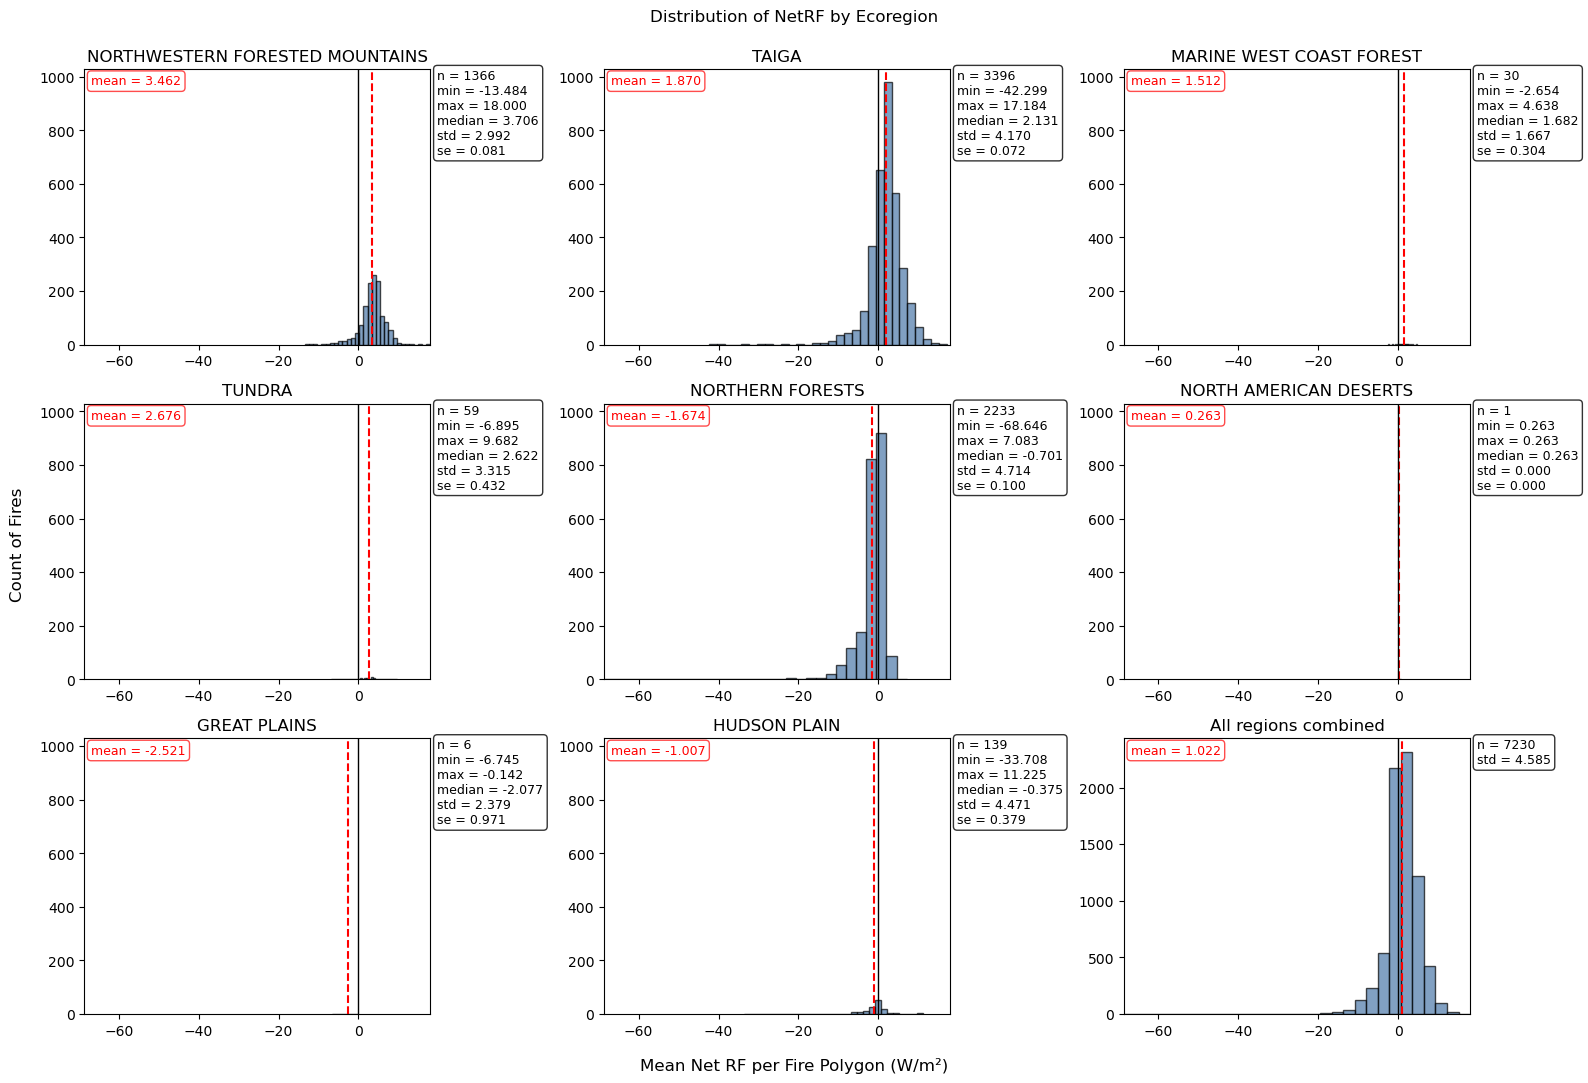

In [7]:
# Create one histogram panel per ecoregion in df_RF, plus one panel for all regions combined.
ecoregions = df_RF["eco"].dropna().unique()
# ecoregions = sorted(
#     r
#     for r in df_RF["eco"].dropna().unique()
#     if r != "NORTH AMERICAN DESERTS" and r != "GREAT PLAINS" and r != "MARINE WEST COAST FOREST"
# )
n_regions = len(ecoregions)
all_values = pd.to_numeric(df_RF['NetRF'], errors='coerce').dropna()

ncols = 3
nrows = int(np.ceil((n_regions + 1) / ncols))

fig = plt.figure(figsize=(16, 3.6 * nrows))
axes = []

for i, eco in enumerate(ecoregions):
    sharey = axes[0] if i > 0 else None
    ax = fig.add_subplot(nrows, ncols, i + 1, sharey=sharey)
    axes.append(ax)

    values = pd.to_numeric(df_RF.loc[df_RF['eco'] == eco, 'NetRF'], errors='coerce').dropna()

    if values.empty:
        ax.axis('off')
        continue

    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std(ddof=1) if len(values) > 1 else 0.0
    sem_val = std_val / np.sqrt(len(values)) if len(values) > 1 else 0.0
    n_fires = len(values)
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"std = {std_val:.3f}\n"
        f"se = {sem_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f'mean = {mean_val:.3f}',
        transform=ax.transAxes,
        color='red',
        fontsize=9,
        ha='left',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
    )

    ax.set_title(eco)
    ax.tick_params(labelbottom=True)

combined_ax = fig.add_subplot(nrows, ncols, n_regions + 1)
combined_mean = all_values.mean()
combined_std = all_values.std(ddof=1) if len(all_values) > 1 else 0.0
combined_n = len(all_values)
combined_ax.hist(all_values, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
combined_ax.axvline(combined_mean, color='red', linestyle='--', linewidth=1.5)
combined_ax.axvline(0, color='black', linestyle='-', linewidth=1)
combined_ax.text(
    0.02,
    0.98,
    f'mean = {combined_mean:.3f}',
    transform=combined_ax.transAxes,
    color='red',
    fontsize=9,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
)
combined_ax.text(
    1.02,
    1.00,
    f'n = {combined_n}\nstd = {combined_std:.3f}',
    transform=combined_ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
)
combined_ax.set_title('All regions combined')
combined_ax.tick_params(labelbottom=True)

x_min = all_values.min()
x_max = all_values.max()
combined_ax.set_xlim(x_min, x_max)
for ax in axes[:n_regions]:
    ax.set_xlim(x_min, x_max)

for idx in range(n_regions + 1, nrows * ncols):
    fig.add_subplot(nrows, ncols, idx + 1).axis('off')

fig.suptitle('Distribution of NetRF by Ecoregion', y=0.995)
fig.supxlabel('Mean Net RF per Fire Polygon (W/m²)')
fig.supylabel('Count of Fires', x=0.01)
plt.tight_layout()
plt.show()

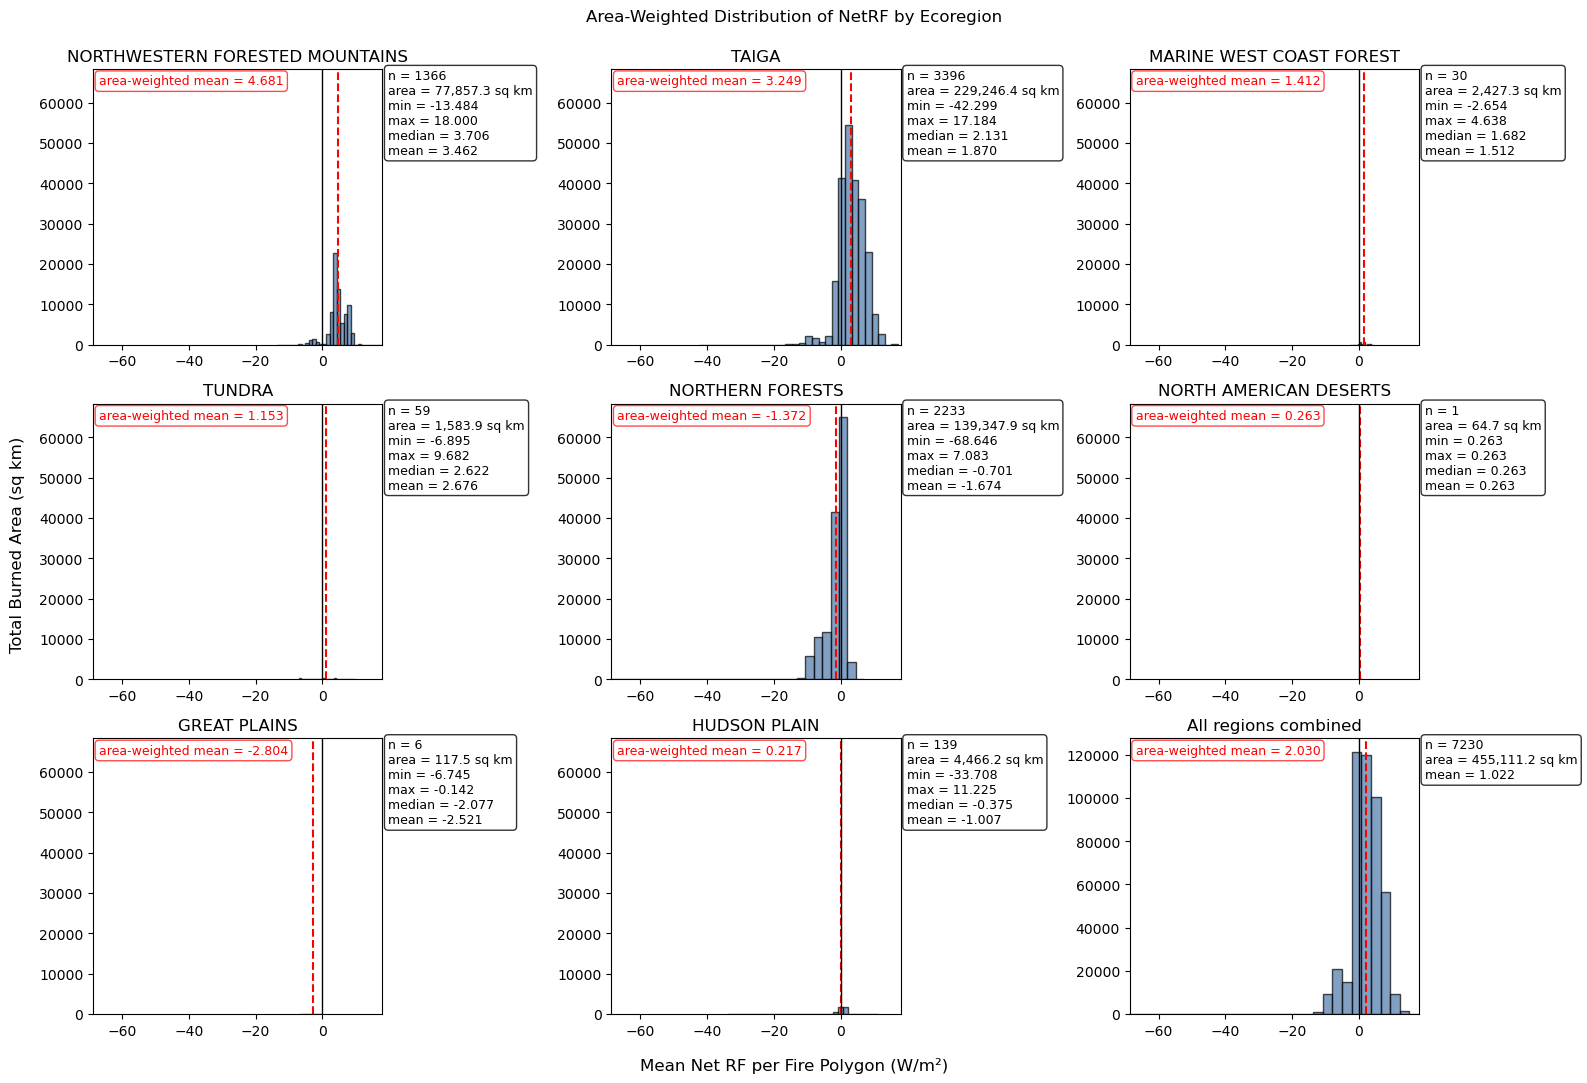

In [10]:
# Recreate Cell 7 with area-weighted histograms (area instead of fire counts).
plot_df = df_filter[["eco", "NetRF", "area_sqkm"]].copy()
plot_df["NetRF"] = pd.to_numeric(plot_df["NetRF"], errors="coerce")
plot_df["area_sqkm"] = pd.to_numeric(plot_df["area_sqkm"], errors="coerce")
plot_df = plot_df.dropna(subset=["eco", "NetRF", "area_sqkm"]).copy()

ecoregions = plot_df["eco"].dropna().unique()
n_regions = len(ecoregions)

all_values = plot_df["NetRF"]
all_weights = plot_df["area_sqkm"]

ncols = 3
nrows = int(np.ceil((n_regions + 1) / ncols))

fig = plt.figure(figsize=(16, 3.6 * nrows))
axes = []

for i, eco in enumerate(ecoregions):
    sharey = axes[0] if i > 0 else None
    ax = fig.add_subplot(nrows, ncols, i + 1, sharey=sharey)
    axes.append(ax)

    sub = plot_df.loc[plot_df["eco"] == eco, ["NetRF", "area_sqkm"]].dropna()
    values = sub["NetRF"]
    weights = sub["area_sqkm"]

    if values.empty:
        ax.axis("off")
        continue

    mean_val = values.mean()
    weighted_mean = np.average(values, weights=weights)
    median_val = values.median()
    n_fires = len(values)
    total_area = weights.sum()
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=30, weights=weights, color="#4C78A8", edgecolor="black", alpha=0.7)
    ax.axvline(weighted_mean, color="red", linestyle="--", linewidth=1.5)
    ax.axvline(0, color="black", linestyle="-", linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"area = {total_area:,.1f} sq km\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"mean = {mean_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f"area-weighted mean = {weighted_mean:.3f}",
        transform=ax.transAxes,
        color="red",
        fontsize=9,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.7),
    )

    ax.set_title(eco)
    ax.tick_params(labelbottom=True)

combined_ax = fig.add_subplot(nrows, ncols, n_regions + 1)
combined_mean = all_values.mean()
combined_weighted_mean = np.average(all_values, weights=all_weights)
combined_n = len(all_values)
combined_area = all_weights.sum()
combined_ax.hist(all_values, bins=30, weights=all_weights, color="#4C78A8", edgecolor="black", alpha=0.7)
combined_ax.axvline(combined_weighted_mean, color="red", linestyle="--", linewidth=1.5)
combined_ax.axvline(0, color="black", linestyle="-", linewidth=1)
combined_ax.text(
    0.02,
    0.98,
    f"area-weighted mean = {combined_weighted_mean:.3f}",
    transform=combined_ax.transAxes,
    color="red",
    fontsize=9,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.7),
)
combined_ax.text(
    1.02,
    1.00,
    f"n = {combined_n}\narea = {combined_area:,.1f} sq km\nmean = {combined_mean:.3f}",
    transform=combined_ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
combined_ax.set_title("All regions combined")
combined_ax.tick_params(labelbottom=True)

x_min = all_values.min()
x_max = all_values.max()
combined_ax.set_xlim(x_min, x_max)
for ax in axes[:n_regions]:
    ax.set_xlim(x_min, x_max)

for idx in range(n_regions + 1, nrows * ncols):
    fig.add_subplot(nrows, ncols, idx + 1).axis("off")

fig.suptitle("Area-Weighted Distribution of NetRF by Ecoregion", y=0.995)
fig.supxlabel("Mean Net RF per Fire Polygon (W/m²)")
fig.supylabel("Total Burned Area (sq km)", x=0.01)
plt.tight_layout()
plt.show()

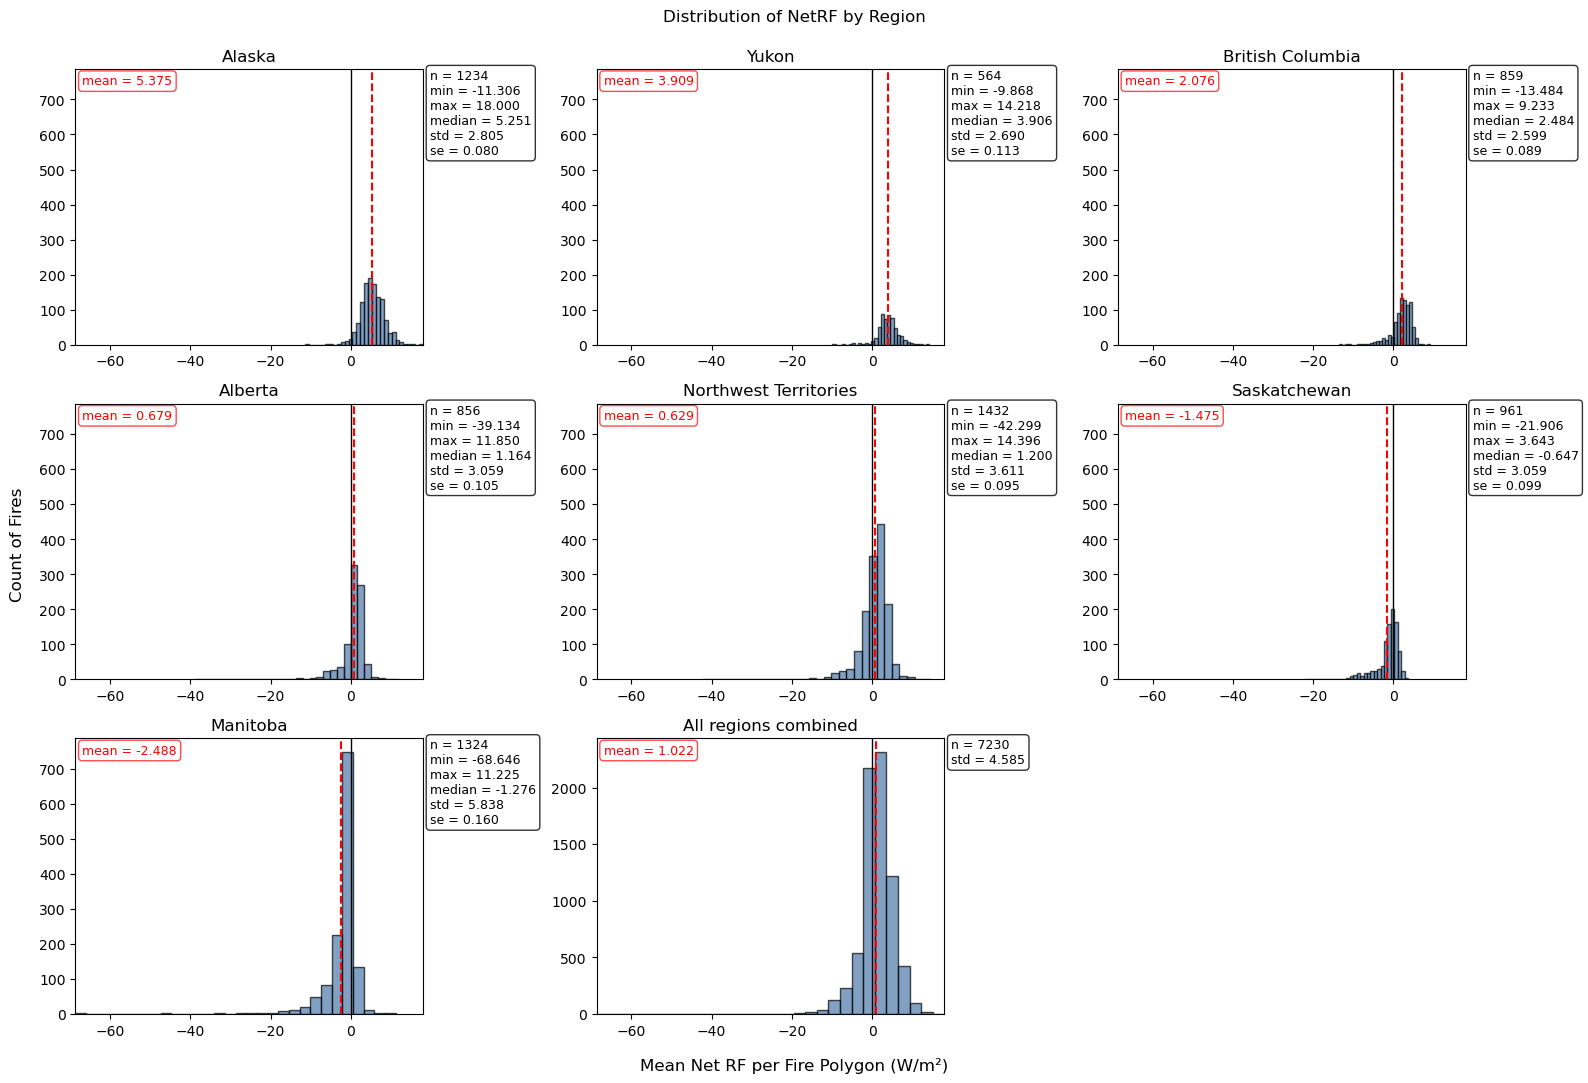

In [9]:
# Create one histogram panel per ecoregion in df_RF, plus one panel for all regions combined.
regions = [eco for eco in df_RF_states['ctry'].dropna().unique() if pd.notna(eco)]
n_regions = len(regions)
all_values = pd.to_numeric(df_RF_states['NetRF'], errors='coerce').dropna()

ncols = 3
nrows = int(np.ceil((n_regions + 1) / ncols))

fig = plt.figure(figsize=(16, 3.6 * nrows))
axes = []

for i, eco in enumerate(regions):
    sharey = axes[0] if i > 0 else None
    ax = fig.add_subplot(nrows, ncols, i + 1, sharey=sharey)
    axes.append(ax)

    values = pd.to_numeric(df_RF_states.loc[df_RF_states['ctry'] == eco, 'NetRF'], errors='coerce').dropna()

    if values.empty:
        ax.axis('off')
        continue

    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std(ddof=1) if len(values) > 1 else 0.0
    sem_val = std_val / np.sqrt(len(values)) if len(values) > 1 else 0.0
    n_fires = len(values)
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"std = {std_val:.3f}\n"
        f"se = {sem_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f'mean = {mean_val:.3f}',
        transform=ax.transAxes,
        color='red',
        fontsize=9,
        ha='left',
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
    )

    ax.set_title(eco)
    ax.tick_params(labelbottom=True)

combined_ax = fig.add_subplot(nrows, ncols, n_regions + 1)
combined_mean = all_values.mean()
combined_std = all_values.std(ddof=1) if len(all_values) > 1 else 0.0
combined_n = len(all_values)
combined_ax.hist(all_values, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
combined_ax.axvline(combined_mean, color='red', linestyle='--', linewidth=1.5)
combined_ax.axvline(0, color='black', linestyle='-', linewidth=1)
combined_ax.text(
    0.02,
    0.98,
    f'mean = {combined_mean:.3f}',
    transform=combined_ax.transAxes,
    color='red',
    fontsize=9,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.7),
)
combined_ax.text(
    1.02,
    1.00,
    f'n = {combined_n}\nstd = {combined_std:.3f}',
    transform=combined_ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
)
combined_ax.set_title('All regions combined')
combined_ax.tick_params(labelbottom=True)

x_min = all_values.min()
x_max = all_values.max()
combined_ax.set_xlim(x_min, x_max)
for ax in axes[:n_regions]:
    ax.set_xlim(x_min, x_max)

for idx in range(n_regions + 1, nrows * ncols):
    fig.add_subplot(nrows, ncols, idx + 1).axis('off')

fig.suptitle('Distribution of NetRF by Region', y=0.995)
fig.supxlabel('Mean Net RF per Fire Polygon (W/m²)')
fig.supylabel('Count of Fires', x=0.01)
plt.tight_layout()
plt.show()

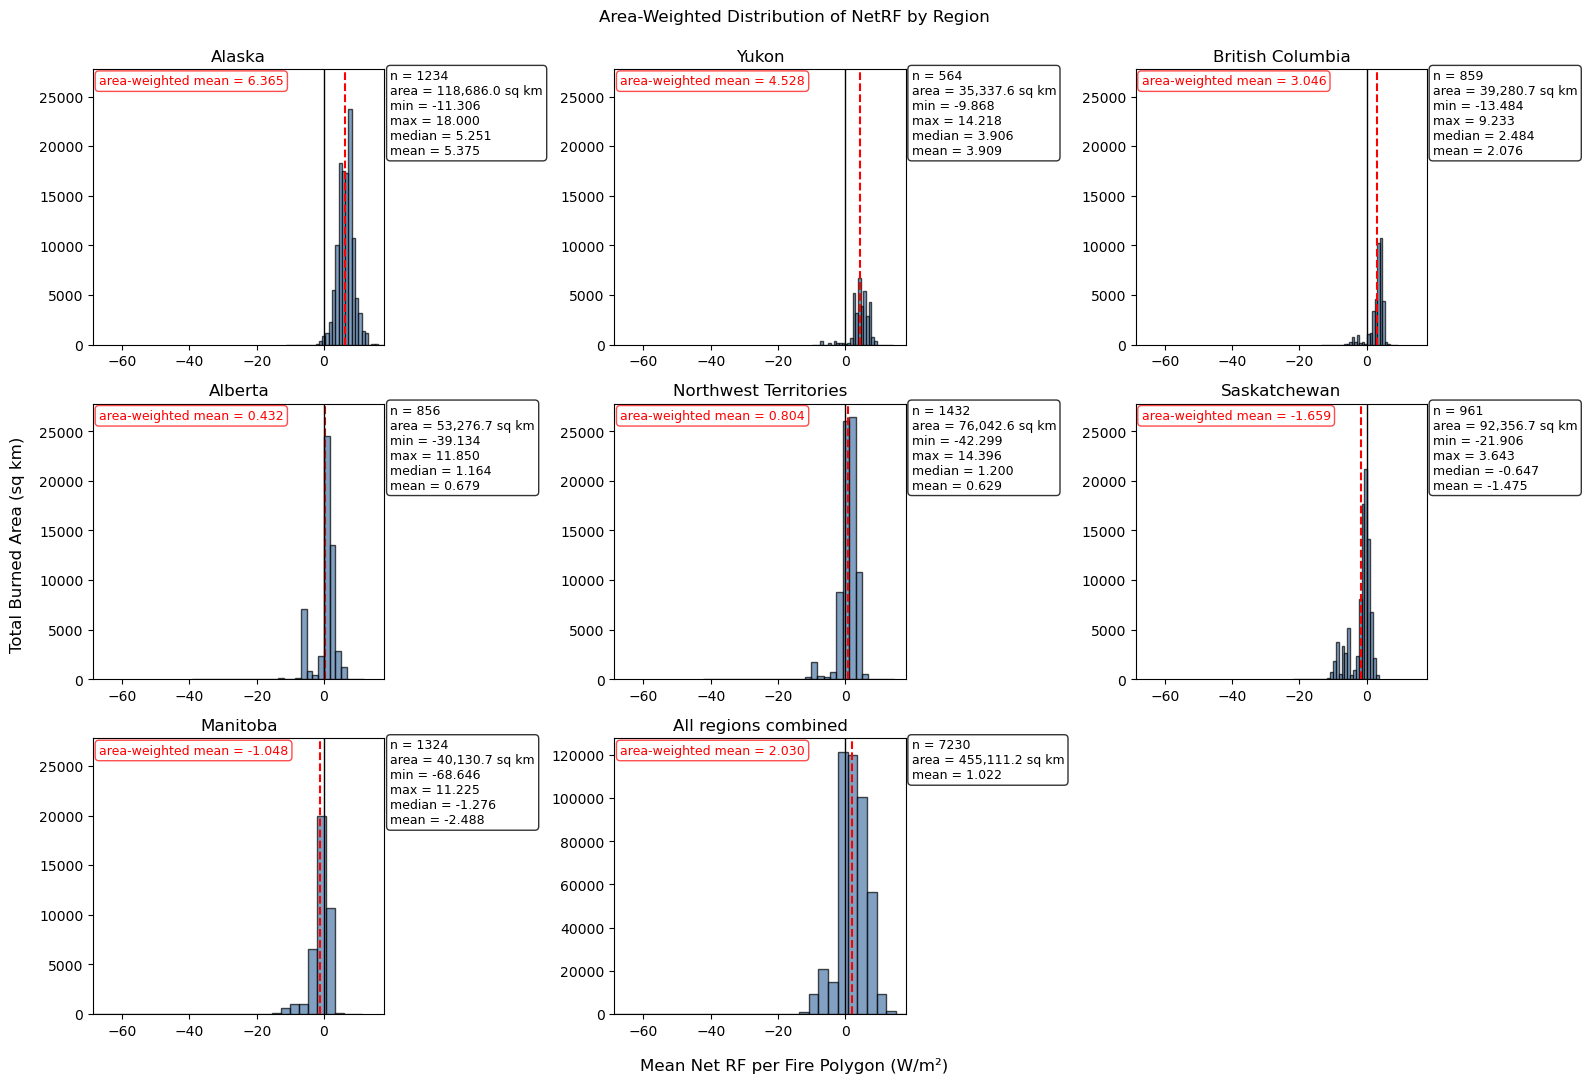

In [11]:
# Recreate the region histogram with area-weighted bins (ctry instead of eco).
plot_df = df_filter[["ctry", "NetRF", "area_sqkm"]].copy()
plot_df["NetRF"] = pd.to_numeric(plot_df["NetRF"], errors="coerce")
plot_df["area_sqkm"] = pd.to_numeric(plot_df["area_sqkm"], errors="coerce")
plot_df = plot_df.dropna(subset=["ctry", "NetRF", "area_sqkm"]).copy()

regions = [r for r in plot_df["ctry"].dropna().unique() if pd.notna(r)]
n_regions = len(regions)

all_values = plot_df["NetRF"]
all_weights = plot_df["area_sqkm"]

ncols = 3
nrows = int(np.ceil((n_regions + 1) / ncols))

fig = plt.figure(figsize=(16, 3.6 * nrows))
axes = []

for i, region in enumerate(regions):
    sharey = axes[0] if i > 0 else None
    ax = fig.add_subplot(nrows, ncols, i + 1, sharey=sharey)
    axes.append(ax)

    sub = plot_df.loc[plot_df["ctry"] == region, ["NetRF", "area_sqkm"]].dropna()
    values = sub["NetRF"]
    weights = sub["area_sqkm"]

    if values.empty:
        ax.axis("off")
        continue

    mean_val = values.mean()
    weighted_mean = np.average(values, weights=weights)
    median_val = values.median()
    n_fires = len(values)
    total_area = weights.sum()
    min_val = values.min()
    max_val = values.max()

    ax.hist(values, bins=30, weights=weights, color="#4C78A8", edgecolor="black", alpha=0.7)
    ax.axvline(weighted_mean, color="red", linestyle="--", linewidth=1.5)
    ax.axvline(0, color="black", linestyle="-", linewidth=1)

    stats_text = (
        f"n = {n_fires}\n"
        f"area = {total_area:,.1f} sq km\n"
        f"min = {min_val:.3f}\n"
        f"max = {max_val:.3f}\n"
        f"median = {median_val:.3f}\n"
        f"mean = {mean_val:.3f}"
    )
    ax.text(
        1.02,
        1.00,
        stats_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.text(
        0.02,
        0.98,
        f"area-weighted mean = {weighted_mean:.3f}",
        transform=ax.transAxes,
        color="red",
        fontsize=9,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.7),
    )

    ax.set_title(region)
    ax.tick_params(labelbottom=True)

combined_ax = fig.add_subplot(nrows, ncols, n_regions + 1)
combined_mean = all_values.mean()
combined_weighted_mean = np.average(all_values, weights=all_weights)
combined_n = len(all_values)
combined_area = all_weights.sum()
combined_ax.hist(all_values, bins=30, weights=all_weights, color="#4C78A8", edgecolor="black", alpha=0.7)
combined_ax.axvline(combined_weighted_mean, color="red", linestyle="--", linewidth=1.5)
combined_ax.axvline(0, color="black", linestyle="-", linewidth=1)
combined_ax.text(
    0.02,
    0.98,
    f"area-weighted mean = {combined_weighted_mean:.3f}",
    transform=combined_ax.transAxes,
    color="red",
    fontsize=9,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.7),
)
combined_ax.text(
    1.02,
    1.00,
    f"n = {combined_n}\narea = {combined_area:,.1f} sq km\nmean = {combined_mean:.3f}",
    transform=combined_ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
combined_ax.set_title("All regions combined")
combined_ax.tick_params(labelbottom=True)

x_min = all_values.min()
x_max = all_values.max()
combined_ax.set_xlim(x_min, x_max)
for ax in axes[:n_regions]:
    ax.set_xlim(x_min, x_max)

for idx in range(n_regions + 1, nrows * ncols):
    fig.add_subplot(nrows, ncols, idx + 1).axis("off")

fig.suptitle("Area-Weighted Distribution of NetRF by Region", y=0.995)
fig.supxlabel("Mean Net RF per Fire Polygon (W/m²)")
fig.supylabel("Total Burned Area (sq km)", x=0.01)
plt.tight_layout()
plt.show()

In [10]:
eco_sums = df_RF.groupby('eco').sum()
eco_sums = eco_sums.sort_values(by='NetRF', ascending=False)
eco_sums

,NetRF,Recovery,Albedo,Permafrost,GHG
eco,,,,,
TAIGA,6350.995297,-1707.278041,-29122.594519,7471.193912,29709.673948
NORTHWESTERN FORESTED MOUNTAINS,4728.568742,-809.158727,-9138.243408,1637.235632,13038.735232
TUNDRA,157.874484,-15.235320,-608.109427,216.510908,564.708322
MARINE WEST COAST FOREST,45.349624,-17.594498,-220.124133,10.768354,272.299902
NORTH AMERICAN DESERTS,0.263189,-0.539984,-8.311454,0.000000,9.114627
GREAT PLAINS,-15.125556,-5.606022,-50.851022,0.000000,41.331488
HUDSON PLAIN,-139.939275,-67.418804,-1777.153348,461.450260,1243.182615
NORTHERN FORESTS,-3737.290289,-1710.132200,-20299.144698,387.637881,17884.348729


In [11]:
df_long = pd.melt(df_RF, id_vars=['eco'], value_vars=['NetRF', 'Recovery', 'Albedo', 'Permafrost', 'GHG'], var_name='Forcing', value_name='Value')
df_long.rename(columns={'eco': 'Ecoregion'}, inplace=True)
df_long['sign'] = df_long['Value'] >= 0
df_long.head()

,Ecoregion,Forcing,Value,sign
0,NORTHWESTERN FORESTED MOUNTAINS,NetRF,-0.695913,False
1,TAIGA,NetRF,5.092502,True
2,TAIGA,NetRF,9.731596,True
3,MARINE WEST COAST FOREST,NetRF,0.379457,True
4,NORTHWESTERN FORESTED MOUNTAINS,NetRF,1.606471,True


In [12]:
import math
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# Required columns in df_RF
component_cols = ['Recovery', 'Albedo', 'Permafrost', 'GHG', 'NetRF']

# Build summary stats: one row per ecoregion x forcing component
eco_stats_df = (
    df_RF.groupby('eco')[component_cols]
    .agg(['mean', 'std', 'count'])
    .stack(level=0, future_stack=True)
    .reset_index()
    .rename(columns={
        'eco': 'Ecoregion',
        'level_1': 'Forcing',
        'mean': 'mean',
        'std': 'std',
        'count': 'n'
    })
)

# Order ecoregions by NetRF mean so the panels are easier to scan
eco_order = eco_stats_df['Ecoregion'].unique().tolist()

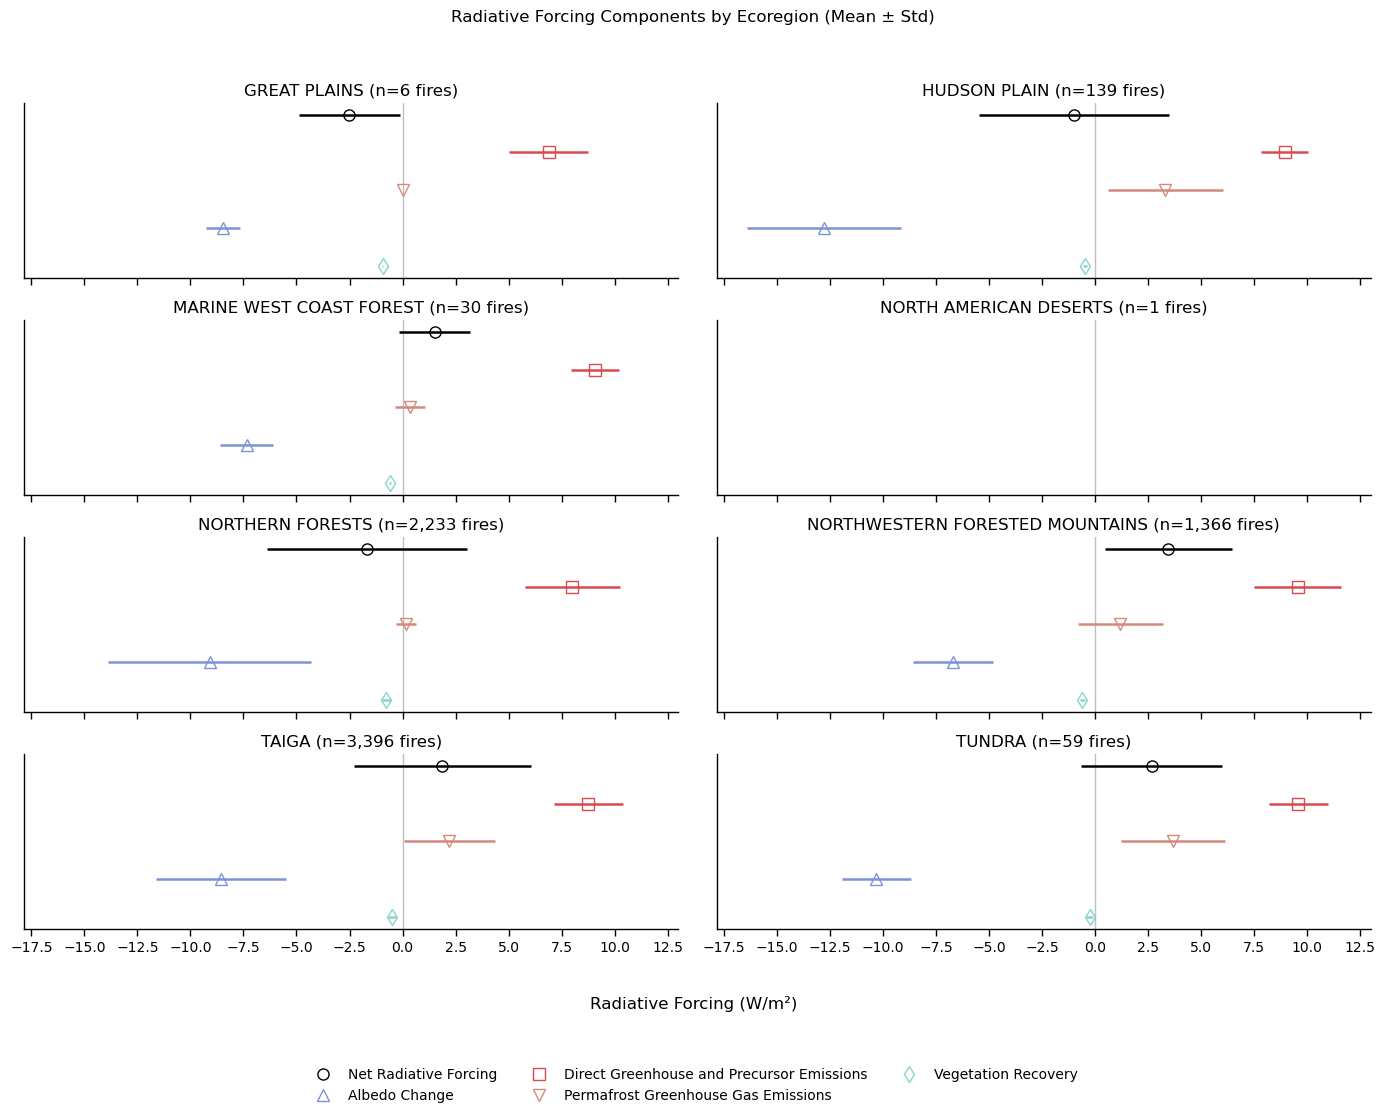

,Ecoregion,Forcing,mean,std,n
0,GREAT PLAINS,Recovery,-0.934337,0.021169,6
1,GREAT PLAINS,Albedo,-8.475170,0.805354,6
2,GREAT PLAINS,Permafrost,0.000000,0.000000,6
3,GREAT PLAINS,GHG,6.888581,1.866272,6
4,GREAT PLAINS,NetRF,-2.520926,2.379414,6
5,HUDSON PLAIN,Recovery,-0.485027,0.089153,139
6,HUDSON PLAIN,Albedo,-12.785276,3.642734,139
7,HUDSON PLAIN,Permafrost,3.319786,2.694474,139
8,HUDSON PLAIN,GHG,8.943760,1.116564,139
9,HUDSON PLAIN,NetRF,-1.006757,4.471035,139


In [13]:
# Mean +/- std plots by ecoregion (same style as the first analysis notebook figure)

# Keep forcing order and style consistent across panels
forcing_order = component_cols
style_map = {
    'NetRF': {'color': '#000000', 'marker': 'o', 'label': 'Net Radiative Forcing'},
    'Albedo': {'color': '#7c94d6', 'marker': '^', 'label': 'Albedo Change'},
    'GHG': {'color': '#d84950', 'marker': 's', 'label': 'Direct Greenhouse and Precursor Emissions'},
    'Permafrost': {'color': '#d3897c', 'marker': 'v', 'label': 'Permafrost Greenhouse Gas Emissions'},
    'Recovery': {'color': '#88d4ca', 'marker': 'd', 'label': 'Vegetation Recovery'}
}

# Plot small multiples: one subplot per ecoregion
n_regions = len(eco_order)
ncols = 2 if n_regions > 1 else 1
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 2.8 * nrows),
    sharex=True
)
axes = np.atleast_1d(axes).ravel()

y_step = 0.16
y_pad = 0.05

for ax, eco in zip(axes, eco_order):
    sub = eco_stats_df[eco_stats_df['Ecoregion'] == eco].copy()
    sub['Forcing'] = pd.Categorical(sub['Forcing'], categories=forcing_order, ordered=True)
    sub = sub.sort_values('Forcing').reset_index(drop=True)

    for i, row in sub.iterrows():
        style = style_map[row['Forcing']]
        y_pos = i * y_step
        if np.isfinite(row['mean']) and np.isfinite(row['std']):
            ax.errorbar(
                row['mean'],
                y_pos,
                xerr=row['std'],
                fmt=style['marker'],
                markersize=8,
                markerfacecolor='none',
                markeredgecolor=style['color'],
                color=style['color'],
                ecolor=style['color'],
                elinewidth=1.8,
                capsize=0,
                linestyle='none'
            )

    n_net = int(sub.loc[sub['Forcing'] == 'NetRF', 'n'].iloc[0]) if not sub.empty else 0
    ax.set_title(f"{eco} (n={n_net:,} fires)")
    ax.set_yticks([])
    ax.set_ylim(-y_pad, (len(forcing_order) - 1) * y_step + y_pad)
    ax.grid(False)
    ax.axvline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)
    ax.xaxis.set_major_locator(MultipleLocator(2.5))
    ax.tick_params(
        axis='x',
        which='major',
        direction='out',
        bottom=True,
        top=False,
        length=5,
        width=1.0,
        colors='black'
    )

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker=style['marker'],
        color='none',
        markeredgecolor=style['color'],
        markerfacecolor='none',
        markersize=8,
        linestyle='none',
        label=style['label']
    )
    for style in style_map.values()
 ]

fig.legend(
    handles=legend_handles,
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.008),
    ncol=3
)

fig.suptitle('Radiative Forcing Components by Ecoregion (Mean ± Std)', y=0.995)
fig.supxlabel('Radiative Forcing (W/m²)', y=0.1)
plt.tight_layout(rect=[0, 0.11, 1, 0.97])
plt.show()

# Optional preview of summary table
eco_stats_df.head(15)

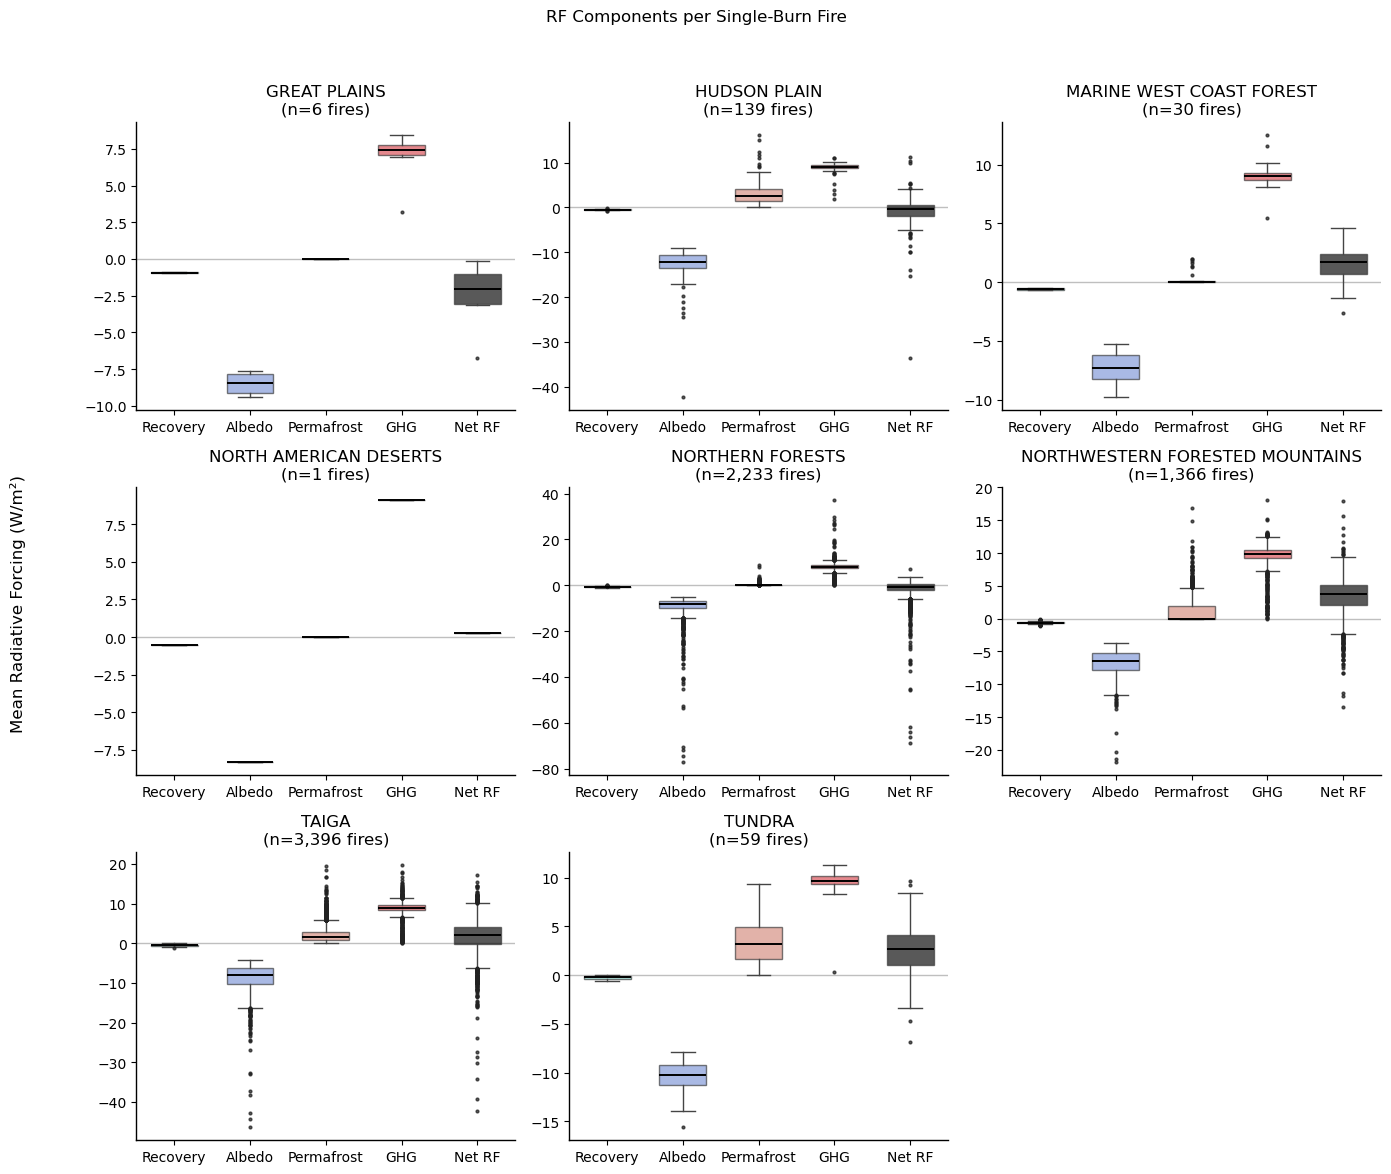

In [14]:
# Boxplot version (uses quartiles/median from raw df_RF values)
# must run previous cell first to define df_RF, eco_order, forcing_order, and style_map

# Toggle: False plots only non-zero values so zero-inflated groups do not collapse to a line at 0
include_zeros = True

n_regions = len(eco_order)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=False
)
axes = np.atleast_1d(axes).ravel()

for ax, eco in zip(axes, eco_order):
    sub_df = df_RF[df_RF['eco'] == eco]

    # Build one array per forcing from raw values; boxplot computes quartiles/whiskers itself
    box_data = []
    for col in forcing_order:
        vals = pd.to_numeric(sub_df[col], errors='coerce').dropna()
        if not include_zeros:
            vals = vals[vals != 0]
        box_data.append(vals.to_numpy(dtype=float))

    # Skip empty panels safely
    if all(arr.size == 0 for arr in box_data):
        ax.axis('off')
        continue

    x = np.arange(len(forcing_order)) + 1
    bplot = ax.boxplot(
        box_data,
        vert=True,
        positions=x,
        widths=0.62,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': 'black', 'linewidth': 1.4},
        whiskerprops={'color': '#444444', 'linewidth': 1.0},
        capprops={'color': '#444444', 'linewidth': 1.0},
        boxprops={'linewidth': 1.0, 'edgecolor': '#333333'},
        flierprops={
            'marker': '.',
            'markerfacecolor': '#222222',
            'markeredgecolor': '#222222',
            'markersize': 4,
            'alpha': 0.75
        }
    )

    for patch, forcing in zip(bplot['boxes'], forcing_order):
        patch.set_facecolor(style_map[forcing]['color'])
        patch.set_alpha(0.65)

    short_labels = {
        'Recovery': 'Recovery',
        'Albedo': 'Albedo',
        'Permafrost': 'Permafrost',
        'GHG': 'GHG',
        'NetRF': 'Net RF'
    }
    labels = [short_labels.get(f, f) for f in forcing_order]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, ha='center', fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")

    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('RF Components per Single-Burn Fire', y=0.995)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

In [16]:
eco_order

['GREAT PLAINS',
 'HUDSON PLAIN',
 'MARINE WEST COAST FOREST',
 'NORTH AMERICAN DESERTS',
 'NORTHERN FORESTS',
 'NORTHWESTERN FORESTED MOUNTAINS',
 'TAIGA',
 'TUNDRA']

/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_8107/963848438.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_8107/963848438.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_labels.get(f, f) for f in forcing_order], ha='center', fontsize=10)
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_8107/963848438.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/sq/yw612wzn25s9n4pclwvt88m40000gq/T/ipykernel_8107/963848438.py:64: UserWarning: set_ticklabels() should only be used 

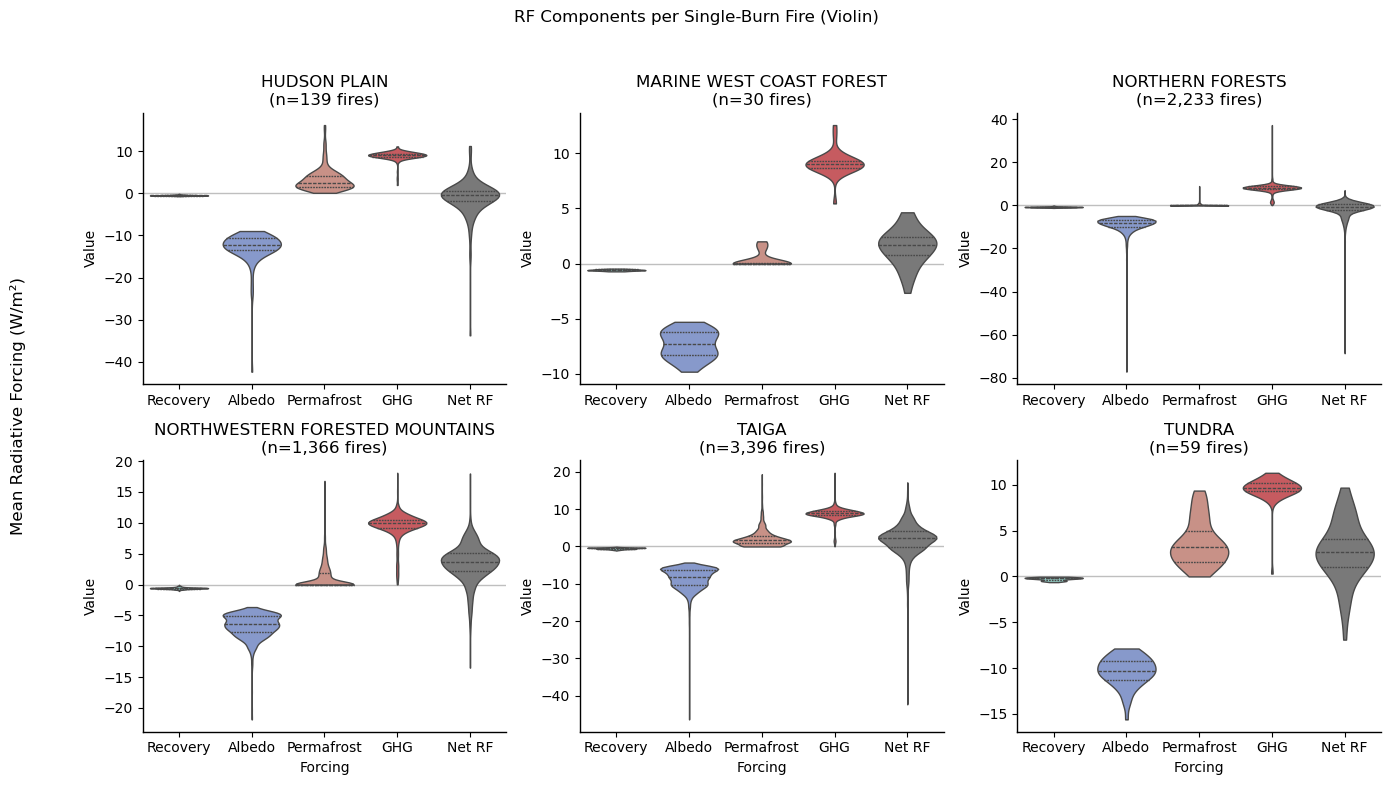

In [18]:
# Violin version of the same per-ecoregion subplot design
# must run previous cell first to define df_RF, eco_order, forcing_order, and style_map

include_zeros = True
regions = [eco for eco in eco_order if eco != "NORTH AMERICAN DESERTS" and eco != "GREAT PLAINS"]
n_regions = len(regions)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=False
)
axes = np.atleast_1d(axes).ravel()

short_labels = {
    'Recovery': 'Recovery',
    'Albedo': 'Albedo',
    'Permafrost': 'Permafrost',
    'GHG': 'GHG',
    'NetRF': 'Net RF'
}
style_map = {
    'NetRF': {'color': "#797979", 'marker': 'o', 'label': 'Net Radiative Forcing'},
    'Albedo': {'color': '#7c94d6', 'marker': '^', 'label': 'Albedo Change'},
    'GHG': {'color': '#d84950', 'marker': 's', 'label': 'Direct Greenhouse and Precursor Emissions'},
    'Permafrost': {'color': '#d3897c', 'marker': 'v', 'label': 'Permafrost Greenhouse Gas Emissions'},
    'Recovery': {'color': '#88d4ca', 'marker': 'd', 'label': 'Vegetation Recovery'}
}
palette_map = {f: style_map[f]['color'] for f in forcing_order}

for ax, eco in zip(axes, regions):
    sub_df = df_RF[df_RF['eco'] == eco]

    plot_rows = []
    for forcing in forcing_order:
        vals = pd.to_numeric(sub_df[forcing], errors='coerce').dropna()
        if not include_zeros:
            vals = vals[vals != 0]
        if vals.size:
            plot_rows.append(pd.DataFrame({'Forcing': forcing, 'Value': vals.values}))

    if not plot_rows:
        ax.axis('off')
        continue

    plot_df = pd.concat(plot_rows, ignore_index=True)

    sns.violinplot(
        data=plot_df,
        x='Forcing',
        y='Value',
        order=forcing_order,
        palette=palette_map,
        cut=0,
        inner='quartile',
        linewidth=1,
        ax=ax
    )

    ax.set_xticklabels([short_labels.get(f, f) for f in forcing_order], ha='center', fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")
    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('RF Components per Single-Burn Fire (Violin)', y=0.995)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

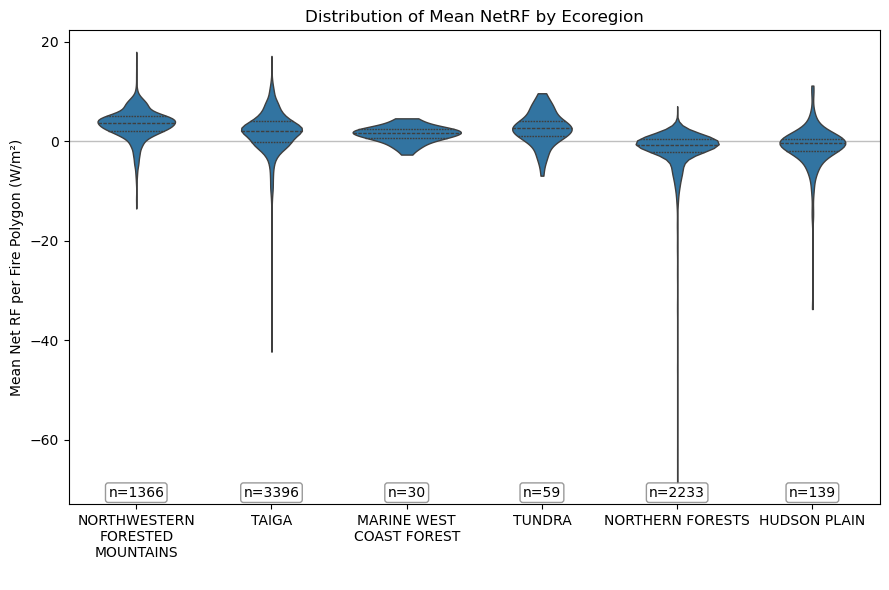

In [12]:
import textwrap

df_copy = df_RF.copy()
df_copy = df_copy[df_copy['eco'] != "NORTH AMERICAN DESERTS"]
df_copy = df_copy[df_copy['eco'] != "GREAT PLAINS"]

region_order = df_copy['eco'].dropna().unique().tolist()
wrapped_labels = [textwrap.fill(label, width=16) for label in region_order]
counts_by_region = df_copy['eco'].value_counts().reindex(region_order).fillna(0).astype(int)

plt.figure(figsize=(9, 6))
ax = sns.violinplot(
    data=df_copy,
    x='eco',
    y='NetRF',
    order=region_order,
    inner='quartile',
    cut=0,
    linewidth=1
)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')

ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
ax.set_xlabel(' ')
ax.set_ylabel('Mean Net RF per Fire Polygon (W/m²)')
ax.set_title('Distribution of Mean NetRF by Ecoregion')

for i, region in enumerate(region_order):
    n_count = int(counts_by_region[region])
    ax.text(
        i,
        ax.get_ylim()[1] * -3.1,
        f'n={n_count}',
        ha='center',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.5', alpha=0.8),
    )

plt.tight_layout()
plt.show()

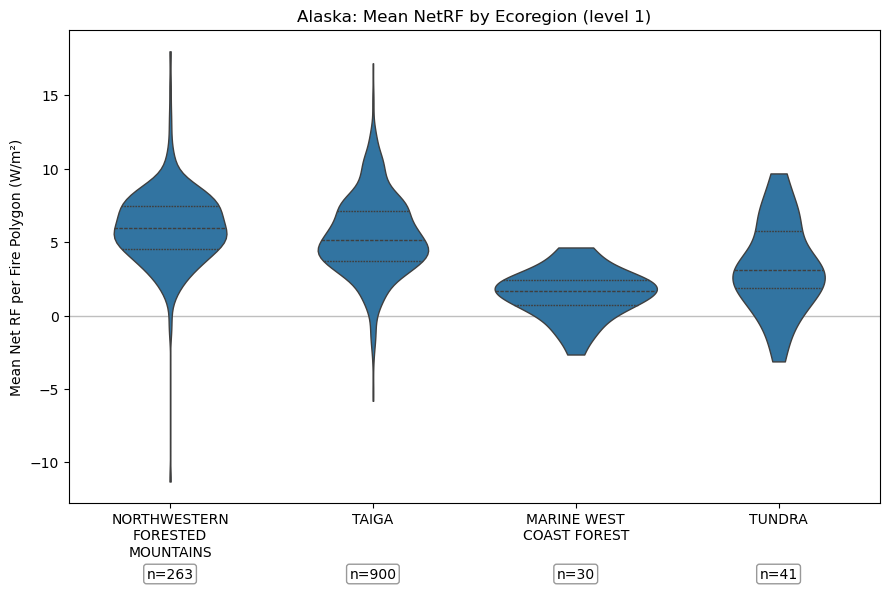

In [21]:
df_copy = df_filter.copy()
df_copy = df_copy[df_copy['ctry'] == "Alaska"]

region_order = df_copy['eco'].dropna().unique().tolist()
wrapped_labels = [textwrap.fill(label, width=16) for label in region_order]
counts_by_region = df_copy['eco'].value_counts().reindex(region_order).fillna(0).astype(int)

plt.figure(figsize=(9, 6))
ax = sns.violinplot(
    data=df_copy,
    x='eco',
    y='NetRF',
    order=region_order,
    inner='quartile',
    cut=0,
    linewidth=1
)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')

ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
ax.set_xlabel(' ')
ax.set_ylabel('Mean Net RF per Fire Polygon (W/m²)')
ax.set_title('Alaska: Mean NetRF by Ecoregion (level 1)')

for i, region in enumerate(region_order):
    n_count = int(counts_by_region[region])
    ax.text(
        i,
        ax.get_ylim()[1] * -0.88,
        f'n={n_count}',
        ha='center',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='0.5', alpha=0.8),
    )

plt.tight_layout()
plt.show()

In [21]:
cats3 = ['eco', 'NetRF', 'PermProb']
filt = df_filter[df_filter['PermProb'] > -9999]
df_perma = filt[cats3]
df_perma.head()

,eco,NetRF,PermProb
0,NORTHWESTERN FORESTED MOUNTAINS,-0.695913,0.858263
1,TAIGA,5.092502,0.446461
2,TAIGA,9.731596,0.441799
3,MARINE WEST COAST FOREST,0.379457,0.000006
4,NORTHWESTERN FORESTED MOUNTAINS,1.606471,0.004664


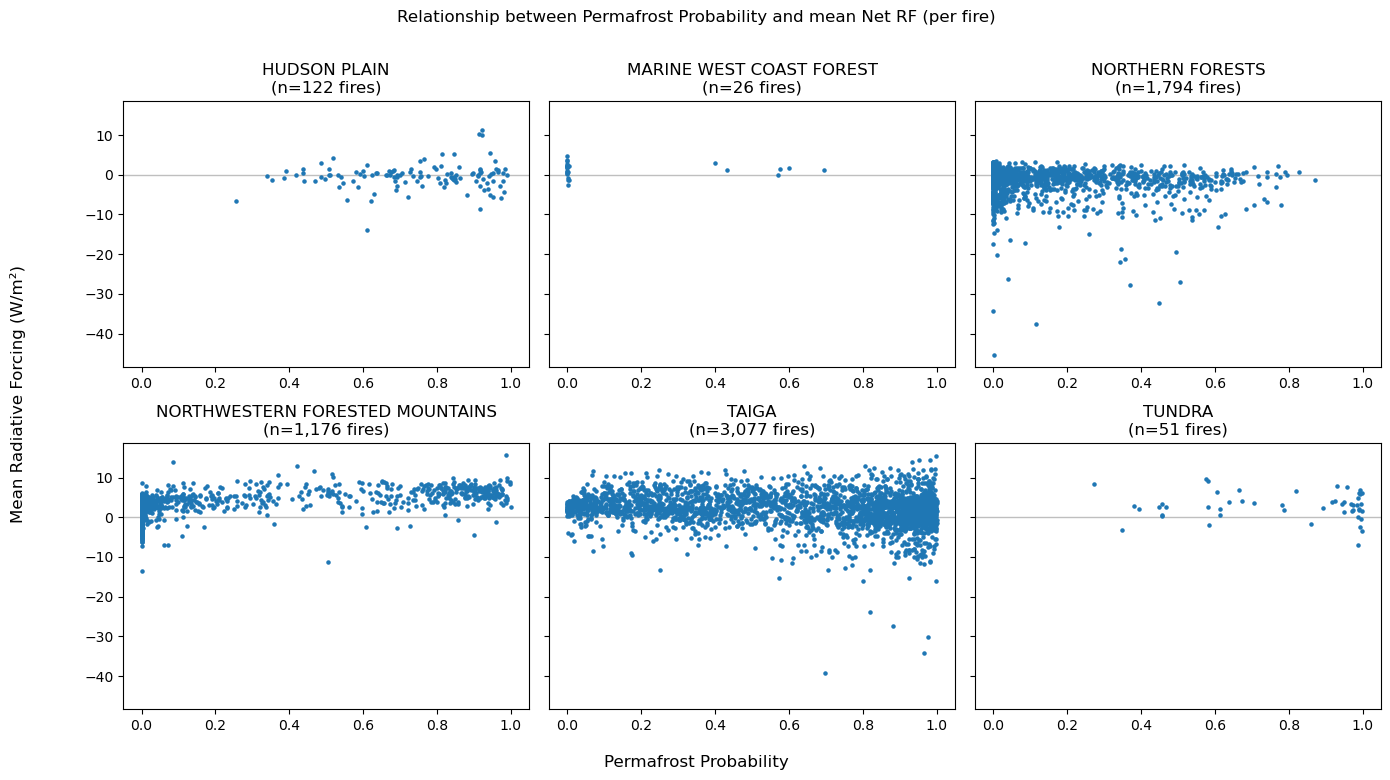

In [24]:
include_zeros = True

regions = [eco for eco in eco_order if eco != "NORTH AMERICAN DESERTS" and eco != "GREAT PLAINS"]
n_regions = len(regions)
ncols = 3 if n_regions > 2 else 2
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(14, 4 * nrows),
    sharex=True,
    sharey=True
)
axes = np.atleast_1d(axes).ravel()

for ax, eco in zip(axes, regions):
    sub_df = df_perma[df_perma['eco'] == eco]
    sub_df = sub_df[sub_df['PermProb'] != -999]

    x = np.arange(len(forcing_order)) + 1
    scat = ax.scatter(
        sub_df['PermProb'],
        sub_df['NetRF'],
        s=5
    )

    ax.tick_params(axis='x', labelbottom=True)

    n_fires = int(len(sub_df))
    ax.set_title(f"{eco}\n(n={n_fires:,} fires)")

    ax.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=0)
    ax.grid(False)

# Hide unused axes if grid is larger than number of ecoregions
for ax in axes[n_regions:]:
    ax.axis('off')

fig.suptitle('Relationship between Permafrost Probability and mean Net RF (per fire)', y=0.98)
fig.supylabel('Mean Radiative Forcing (W/m²)', x=0.01)
fig.supxlabel('Permafrost Probability', y=0.03)
plt.tight_layout(rect=[0.03, 0.02, 1, 0.97])
plt.show()

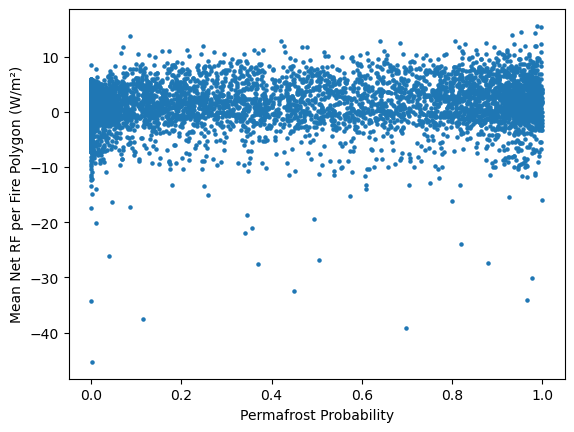

In [27]:
sub_df = df_perma[df_perma['PermProb'] != -999]
plt.scatter(sub_df['PermProb'], sub_df['NetRF'], s=5)
plt.xlabel("Permafrost Probability")
plt.ylabel("Mean Net RF per Fire Polygon (W/m²)")
plt.show()


In [33]:
#number of fires in each each RF category per region
bins = [-100, -2.5, -0.5, 0.5, 2.5, 100]
labels = ['Extreme Cooling', 'Cooling', 'Neutral', 'Warming', 'Extreme Warming']

df_cats = df_filter.copy()
df_cats['category'] = pd.cut(df_cats['NetRF'], bins=bins, labels=labels)
df_cats.head()

#df_cats.to_csv('/Users/hrchapmandutton/Documents/Projects/CDW/fires_2001_2019_RFcategories.csv')

,FID,NAME,RECORDNUMB,ACRES,PERIMETERD,SOURCE,SOURCEMETH,SOURCECLAS,AGENCYACRE,COMMENTS,...,Recovery,NetRF,PermProb,PermCat,ClimateCat,MaxsAreaKm,PerMaxData,MaxData,FrClpAreKm,category
0,0,Boundary River,362,14229.39,2020-09-06 0:00:00,Image Interpretation,,,0.0,Update from USGS 2024. Perimeter incorporated ...,...,-0.600374,-0.695913,0.858263,Discontinuous,Cooling,47.489062,82.796375,1,57.356451,Cooling
1,1,Old Grouch Top,174,224907.36,2020-08-18 0:00:00,Image Interpretation,,,0.0,Update from USGS 2024. Northern portion update...,...,-0.644792,5.092502,0.446461,Sporadic,Extreme Warming,725.959690,86.080492,1,843.349839,Extreme Warming
2,2,Tom Cook Slough,526,7035.06,2020-08-18 0:00:00,Image Interpretation,,,0.0,Update from USGS 2024. Perimeter incorporated ...,...,-0.389494,9.731596,0.441799,Sporadic,Extreme Warming,18.769737,70.090972,1,26.779108,Extreme Warming
3,3,Swan Lake,181,164803.10,2020-07-20 0:00:00,Image Interpretation,,,0.0,Update from USGS 2024. Perimeter incorporated ...,...,-0.528114,0.379457,0.000006,,Neutral,436.740328,65.944407,1,662.285623,Neutral
4,4,Long,484,236.35,2020-06-27 0:00:00,Image Interpretation,Image,,0.0,Perimeter modified from Sentinel-2 image acqui...,...,-0.620474,1.606471,0.004664,Isolated,Warming,0.330009,34.502131,1,0.956487,Warming


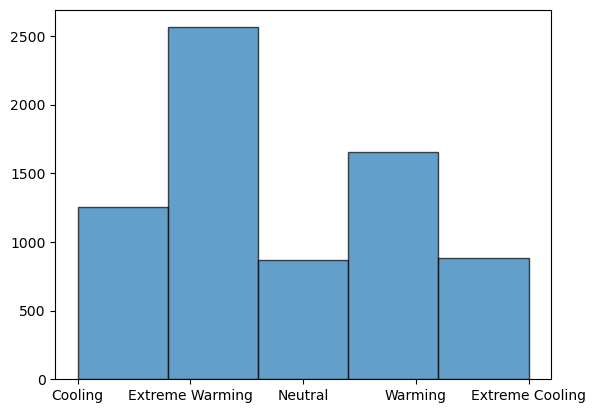

In [34]:
plt.figure()
plt.hist(df_cats['category'], bins=len(labels), edgecolor='black', alpha=0.7)
plt.show()